# Ultimate YOLO11 Football Tracking Comparison

One CPU-only, no-training experiment notebook for four complete videos and
three tracking methods:

1. YOLO11 + OC-SORT
2. YOLO11 + Deep OC-SORT
3. YOLO11 + Deep OC-SORT + hard-scene-cut identity recovery

This notebook is built incrementally. Every completed section is executed and
validated before the next experiment stage is added.

## tl;dr — final experiment checkpoint

All **12 full-duration videos** are complete: four sources × OC-SORT, Deep OC-SORT,
and Deep OC-SORT + scene-cut recovery. Every H.264 output was validated against its
source frame count and 30 FPS. The separate gallery at `outputs/reports/video_gallery.html`
contains all twelve videos; this notebook contains tables and figures only.

The cut-aware method detected **44 hard-cut events** and made **202**
conservative OSNet-based recovery decisions. Mean accepted similarity was 0.843,
0.859, 0.879, and 0.800 for football-1, football-2, football-3, and MI6 respectively.

No HOTA, IDF1, MOTA, true identity-switch count, or ReID accuracy is claimed because
the four custom videos do not provide identity ground truth. Deep OC-SORT throughput
excludes the separately measured one-time OSNet appearance-cache construction.

## Context & Methods

### Key assumptions

- Execution is CPU-only.
- YOLO11n uses pretrained COCO weights and detects only class `person`.
- Every source frame is processed; no sampling or frame limit is allowed.
- A cache is valid only if its fingerprint, frame count, width, and height match
  the corresponding source.
- Custom videos have no identity ground truth. Detector and runtime diagnostics
  are observable, but tracking accuracy metrics such as HOTA and IDF1 require
  annotations and will not be fabricated.

## Setup

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from scenecut_tracking.config import load_config
from scenecut_tracking.detection_cache import DetectionCache, build_detection_cache
from scenecut_tracking.detector import YoloPersonDetector
from scenecut_tracking.frame_source import read_source_metadata

CONFIG_PATH = PROJECT_ROOT / "configs" / "ultimate_cpu.yaml"
CONFIG = load_config(CONFIG_PATH)
VIDEO_PATHS = {
    name: PROJECT_ROOT / relative_path
    for name, relative_path in CONFIG["experiment"]["videos"].items()
}
CACHE_ROOT = PROJECT_ROOT / CONFIG["experiment"]["detection_cache_root"]
FIGURE_ROOT = PROJECT_ROOT / "outputs" / "comparisons" / "figures"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

REBUILD_DETECTION_CACHES = False
np.random.seed(42)

COLORS = {
    "football-1": "#2563EB",
    "football-2": "#D97706",
    "football-3": "#7C3AED",
    "MI6": "#0F766E",
}
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.22,
    "font.size": 11,
})

print(f"Project: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")
print(f"Python: {platform.python_version()}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {CONFIG['experiment']['device']}")
print(f"Process all frames: {CONFIG['experiment']['process_all_frames']}")

Project: D:\Bunker\BaseCamp\SceneCut Aware tracking
Config: D:\Bunker\BaseCamp\SceneCut Aware tracking\configs\ultimate_cpu.yaml
Python: 3.12.12
PyTorch: 2.14.0+cpu
Device: cpu
Process all frames: True


## Data — validate the four canonical inputs

In [2]:
input_rows = []
for video_name, video_path in VIDEO_PATHS.items():
    assert video_path.is_file(), f"Missing input video: {video_path}"
    metadata = read_source_metadata(video_path)
    input_rows.append({
        "video": video_name,
        "frames": metadata.frame_count,
        "fps": metadata.fps,
        "duration_seconds": metadata.frame_count / metadata.fps,
        "resolution": f"{metadata.width}x{metadata.height}",
        "fingerprint": metadata.fingerprint[:12],
        "path": str(video_path.relative_to(PROJECT_ROOT)),
    })

input_summary = pd.DataFrame(input_rows)
assert {"football-1", "football-2", "football-3", "MI6"}.issubset(set(input_summary["video"]))
assert (input_summary["frames"] > 0).all()
assert (input_summary["fps"] > 0).all()
display(input_summary.style.format({"fps": "{:.2f}", "duration_seconds": "{:.2f}"}))

,video,frames,fps,duration_seconds,resolution,fingerprint,path
0,football-1,1122,30.00,37.40,1232x642,f56949b3f1f1,data\videos\desktop_clips\football-1.mp4
1,football-2,722,30.00,24.07,1264x650,892f9f6105df,data\videos\desktop_clips\football-2.mp4
2,football-3,842,30.00,28.07,1274x718,19ca8d548558,data\videos\desktop_clips\football-3.mp4
3,MI6,918,30.00,30.60,1300x540,bcb65b9b1f61,data\MI6.mp4


## Step 3 — shared YOLO11 detection caches

In [3]:
detector = YoloPersonDetector(CONFIG["detector"], PROJECT_ROOT)
cache_results: dict[str, dict] = {}

def build_or_validate_cache(video_name: str) -> dict:
    video_path = VIDEO_PATHS[video_name]
    cache_path = CACHE_ROOT / f"{video_name}_yolo11n_cpu.npz"

    if cache_path.exists() and not REBUILD_DETECTION_CACHES:
        cache = DetectionCache.load(cache_path)
        action = "validated existing cache"
    else:
        print(f"Running pretrained YOLO11n on every frame of {video_name}...")
        cache = build_detection_cache(video_path, detector, CONFIG["detector"])
        cache.save(cache_path)
        action = "built new cache"

    source_metadata = cache.validate_source(video_path)
    cached_video = cache.metadata["video"]
    runtime = cache.metadata["runtime"]
    assert cached_video["frame_count"] == source_metadata.frame_count
    assert cached_video["width"] == source_metadata.width
    assert cached_video["height"] == source_metadata.height
    assert cache.metadata["detector"]["model"] == "yolo11n.pt"
    assert cache.metadata["detector"]["device"] == "cpu"

    result = {
        "video": video_name,
        "status": action,
        "source_frames": source_metadata.frame_count,
        "cache_frames": cached_video["frame_count"],
        "detection_rows": runtime["detection_rows"],
        "elapsed_seconds": runtime["elapsed_seconds"],
        "detector_fps": runtime["processing_fps"],
        "mean_detections_per_frame": runtime["detection_rows"] / source_metadata.frame_count,
        "cache_path": str(cache_path.relative_to(PROJECT_ROOT)),
    }
    cache_results[video_name] = result
    return result

In [4]:
football_1_cache = build_or_validate_cache('football-1')
football_1_cache

{'video': 'football-1',
 'status': 'validated existing cache',
 'source_frames': 1122,
 'cache_frames': 1122,
 'detection_rows': 8364,
 'elapsed_seconds': 90.97811380000348,
 'detector_fps': 12.332636423596167,
 'mean_detections_per_frame': 7.454545454545454,
 'cache_path': 'outputs\\detection_cache\\football-1_yolo11n_cpu.npz'}

In [5]:
football_2_cache = build_or_validate_cache('football-2')
football_2_cache

{'video': 'football-2',
 'status': 'validated existing cache',
 'source_frames': 722,
 'cache_frames': 722,
 'detection_rows': 6179,
 'elapsed_seconds': 60.42967139999382,
 'detector_fps': 11.947773060372356,
 'mean_detections_per_frame': 8.558171745152354,
 'cache_path': 'outputs\\detection_cache\\football-2_yolo11n_cpu.npz'}

In [6]:
football_3_cache = build_or_validate_cache('football-3')
football_3_cache

{'video': 'football-3',
 'status': 'validated existing cache',
 'source_frames': 842,
 'cache_frames': 842,
 'detection_rows': 13947,
 'elapsed_seconds': 70.7509407999969,
 'detector_fps': 11.900901818114578,
 'mean_detections_per_frame': 16.56413301662708,
 'cache_path': 'outputs\\detection_cache\\football-3_yolo11n_cpu.npz'}

In [7]:
mi6_cache = build_or_validate_cache('MI6')
mi6_cache

{'video': 'MI6',
 'status': 'validated existing cache',
 'source_frames': 918,
 'cache_frames': 918,
 'detection_rows': 4203,
 'elapsed_seconds': 77.23317569999926,
 'detector_fps': 11.88608381928815,
 'mean_detections_per_frame': 4.578431372549019,
 'cache_path': 'outputs\\detection_cache\\MI6_yolo11n_cpu.npz'}

## Results — detection-cache audit

In [8]:
detection_summary = pd.DataFrame(cache_results.values()).sort_values("video").reset_index(drop=True)
assert len(detection_summary) == 4
assert (detection_summary["source_frames"] == detection_summary["cache_frames"]).all()
assert (detection_summary["detection_rows"] > 0).all()
assert (detection_summary["detector_fps"] > 0).all()

display(
    detection_summary.style.format({
        "elapsed_seconds": "{:.2f}",
        "detector_fps": "{:.2f}",
        "mean_detections_per_frame": "{:.2f}",
    })
)
print("PASS: all four caches cover every source frame and match source provenance.")

,video,status,source_frames,cache_frames,detection_rows,elapsed_seconds,detector_fps,mean_detections_per_frame,cache_path
0,MI6,validated existing cache,918,918,4203,77.23,11.89,4.58,outputs\detection_cache\MI6_yolo11n_cpu.npz
1,football-1,validated existing cache,1122,1122,8364,90.98,12.33,7.45,outputs\detection_cache\football-1_yolo11n_cpu.npz
2,football-2,validated existing cache,722,722,6179,60.43,11.95,8.56,outputs\detection_cache\football-2_yolo11n_cpu.npz
3,football-3,validated existing cache,842,842,13947,70.75,11.90,16.56,outputs\detection_cache\football-3_yolo11n_cpu.npz


PASS: all four caches cover every source frame and match source provenance.


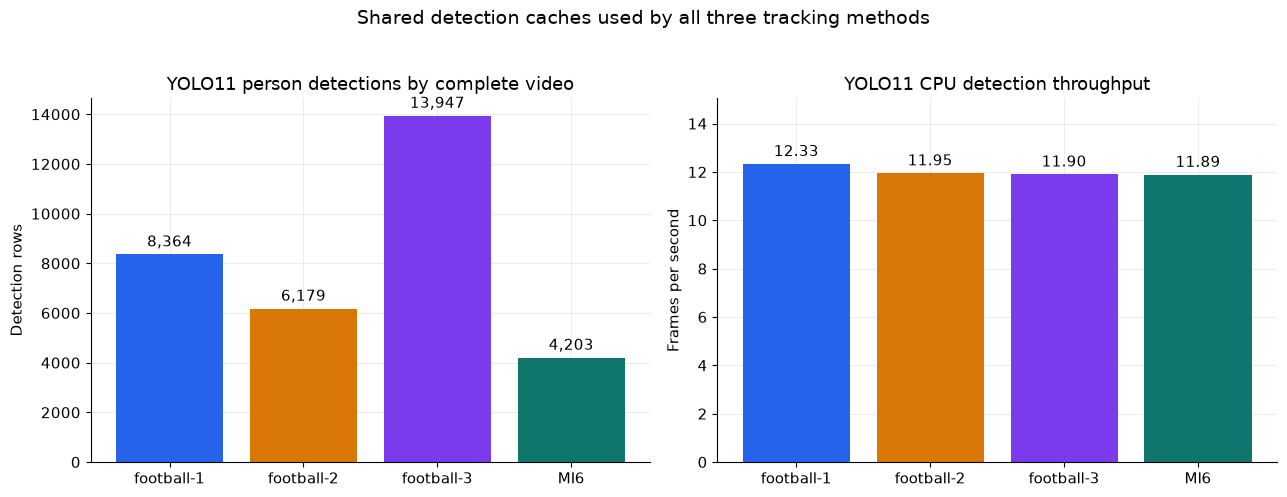

Saved figure: outputs\comparisons\figures\step3_yolo11_detection_cache_summary.png


In [9]:
ordered = detection_summary.set_index("video").loc[["football-1", "football-2", "football-3", "MI6"]]
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bar_colors = [COLORS[name] for name in ordered.index]

detection_bars = axes[0].bar(ordered.index, ordered["detection_rows"], color=bar_colors)
axes[0].set_title("YOLO11 person detections by complete video")
axes[0].set_ylabel("Detection rows")
axes[0].set_xlabel("")
axes[0].bar_label(detection_bars, fmt="{:,.0f}", padding=3)

fps_bars = axes[1].bar(ordered.index, ordered["detector_fps"], color=bar_colors)
axes[1].set_title("YOLO11 CPU detection throughput")
axes[1].set_ylabel("Frames per second")
axes[1].set_xlabel("")
axes[1].bar_label(fps_bars, fmt="%.2f", padding=3)
axes[1].set_ylim(0, max(ordered["detector_fps"]) * 1.22)

figure.suptitle("Shared detection caches used by all three tracking methods", fontsize=14, y=1.03)
figure.tight_layout()
figure_path = FIGURE_ROOT / "step3_yolo11_detection_cache_summary.png"
figure.savefig(figure_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved figure: {figure_path.relative_to(PROJECT_ROOT)}")

## Takeaways — Step 3

- Cache coverage is complete: **3,604/3,604 frames**.
- `football-3` contains the most person proposals
  (13,947), while `football-1` had the highest
  measured CPU detector throughput (12.33 FPS).
- Detection count is **not** detector accuracy. A high count can include duplicates
  or false positives; a low count can indicate missed distant players.
- The caches establish a controlled detector input for the tracker comparison.
  Identity accuracy claims still require annotated identity ground truth.

The next section will run OC-SORT against these four immutable caches.

## Step 4 — YOLO11 + OC-SORT baseline

OC-SORT is the motion-only baseline. YOLO11 provides person boxes; OC-SORT
uses Kalman motion prediction, observation-centric updates, and IoU-based
association to assign track IDs. Appearance embeddings and scene-cut logic
are disabled in this stage.

Each video is processed completely from its immutable Step 3 cache.

In [10]:
import shutil

from scenecut_tracking.runner import run_video
from scenecut_tracking.runtime import write_json
from scenecut_tracking.video_export import make_browser_video

EXPERIMENT_ROOT = PROJECT_ROOT / CONFIG["experiment"]["output_root"]
ocsort_results: dict[str, dict] = {}

def inspect_video(path: Path) -> dict:
    capture = cv2.VideoCapture(str(path))
    if not capture.isOpened():
        raise RuntimeError(f"Cannot open video: {path}")
    frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(capture.get(cv2.CAP_PROP_FPS))
    width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    capture.release()
    if fps <= 0:
        raise AssertionError(f"Invalid FPS for {path}: {fps}")
    return {
        "frames": frames,
        "fps": fps,
        "duration_seconds": frames / fps,
        "width": width,
        "height": height,
    }

def standardize_ocsort_artifacts(output_dir: Path, metrics: dict) -> dict:
    generated_video = output_dir / "annotated_baseline.mp4"
    standard_video = output_dir / "annotated.mp4"
    browser_video = output_dir / "annotated_h264.mp4"

    if generated_video.exists():
        if standard_video.exists():
            standard_video.unlink()
        generated_video.replace(standard_video)
    if not standard_video.exists():
        raise FileNotFoundError(standard_video)
    if not browser_video.exists():
        make_browser_video(standard_video, browser_video)

    plots_dir = output_dir / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    for plot_name in ("active_identities_over_time.png", "track_duration_distribution.png"):
        generated_plot = output_dir / plot_name
        if generated_plot.exists():
            destination = plots_dir / plot_name
            if destination.exists():
                destination.unlink()
            generated_plot.replace(destination)

    metrics["mode"] = "ocsort"
    metrics["method"] = "YOLO11 + OC-SORT"
    metrics["annotated_video"] = str(standard_video)
    metrics["browser_video"] = str(browser_video)
    write_json(metrics, output_dir / "metrics.json")
    return metrics

def run_or_validate_ocsort(video_name: str) -> dict:
    video_path = VIDEO_PATHS[video_name]
    cache_path = CACHE_ROOT / f"{video_name}_yolo11n_cpu.npz"
    output_dir = EXPERIMENT_ROOT / video_name / "ocsort"
    metrics_path = output_dir / "metrics.json"
    standard_video = output_dir / "annotated.mp4"
    browser_video = output_dir / "annotated_h264.mp4"

    if metrics_path.exists() and standard_video.exists() and browser_video.exists():
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        status = "validated existing run"
    else:
        print(f"Running OC-SORT on every frame of {video_name}...")
        metrics = run_video(
            mode="baseline",
            video_path=video_path,
            detection_cache_path=cache_path,
            output_dir=output_dir,
            config=CONFIG,
            project_root=PROJECT_ROOT,
        )
        metrics = standardize_ocsort_artifacts(output_dir, metrics)
        status = "built new run"

    source_meta = inspect_video(video_path)
    standard_meta = inspect_video(standard_video)
    browser_meta = inspect_video(browser_video)
    assert metrics["frames"] == source_meta["frames"]
    assert standard_meta["frames"] == source_meta["frames"]
    assert browser_meta["frames"] == source_meta["frames"]
    assert abs(standard_meta["fps"] - source_meta["fps"]) < 0.01
    assert abs(browser_meta["fps"] - source_meta["fps"]) < 0.01
    assert abs(browser_meta["duration_seconds"] - source_meta["duration_seconds"]) < 0.05

    tracks = pd.read_csv(output_dir / "tracks.csv")
    box_columns = ["x1", "y1", "x2", "y2"]
    assert len(tracks) == metrics["track_rows"]
    assert np.isfinite(tracks[box_columns].to_numpy()).all()
    assert (tracks["global_id"] == tracks["local_id"]).all()

    result = {
        "video": video_name,
        "method": "OC-SORT",
        "status": status,
        "source_frames": source_meta["frames"],
        "output_frames": browser_meta["frames"],
        "duration_seconds": browser_meta["duration_seconds"],
        "processing_fps": metrics["processing_fps"],
        "elapsed_seconds": metrics["elapsed_seconds"],
        "track_rows": metrics["track_rows"],
        "unique_global_ids": metrics["unique_global_ids"],
        "finite_track_boxes": True,
        "output_dir": str(output_dir.relative_to(PROJECT_ROOT)),
    }
    ocsort_results[video_name] = result
    return result

In [11]:
football_1_ocsort = run_or_validate_ocsort('football-1')
football_1_ocsort

{'video': 'football-1',
 'method': 'OC-SORT',
 'status': 'validated existing run',
 'source_frames': 1122,
 'output_frames': 1122,
 'duration_seconds': 37.4,
 'processing_fps': 24.91705773270638,
 'elapsed_seconds': 45.02939360000164,
 'track_rows': 6243,
 'unique_global_ids': 216,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-1\\ocsort'}

In [12]:
football_2_ocsort = run_or_validate_ocsort('football-2')
football_2_ocsort

{'video': 'football-2',
 'method': 'OC-SORT',
 'status': 'validated existing run',
 'source_frames': 722,
 'output_frames': 722,
 'duration_seconds': 24.066666666666666,
 'processing_fps': 24.63255150399065,
 'elapsed_seconds': 29.310808500005805,
 'track_rows': 4704,
 'unique_global_ids': 194,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-2\\ocsort'}

In [13]:
football_3_ocsort = run_or_validate_ocsort('football-3')
football_3_ocsort

{'video': 'football-3',
 'method': 'OC-SORT',
 'status': 'validated existing run',
 'source_frames': 842,
 'output_frames': 842,
 'duration_seconds': 28.066666666666666,
 'processing_fps': 18.5786307759153,
 'elapsed_seconds': 45.32088560000557,
 'track_rows': 9287,
 'unique_global_ids': 457,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-3\\ocsort'}

In [14]:
mi6_ocsort = run_or_validate_ocsort('MI6')
mi6_ocsort

{'video': 'MI6',
 'method': 'OC-SORT',
 'status': 'validated existing run',
 'source_frames': 918,
 'output_frames': 918,
 'duration_seconds': 30.6,
 'processing_fps': 37.79642525856786,
 'elapsed_seconds': 24.288011199998436,
 'track_rows': 3613,
 'unique_global_ids': 110,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\MI6\\ocsort'}

### OC-SORT full-frame validation

In [15]:
ocsort_summary = pd.DataFrame(ocsort_results.values()).set_index("video").loc[
    ["football-1", "football-2", "football-3", "MI6"]
].reset_index()
assert len(ocsort_summary) == 4
assert (ocsort_summary["source_frames"] == ocsort_summary["output_frames"]).all()
assert ocsort_summary["finite_track_boxes"].all()
assert (ocsort_summary["processing_fps"] > 0).all()

display(
    ocsort_summary.style.format({
        "duration_seconds": "{:.2f}",
        "processing_fps": "{:.2f}",
        "elapsed_seconds": "{:.2f}",
    })
)
print("PASS: all four OC-SORT videos contain every source frame at the source FPS.")

,video,method,status,source_frames,output_frames,duration_seconds,processing_fps,elapsed_seconds,track_rows,unique_global_ids,finite_track_boxes,output_dir
0,football-1,OC-SORT,validated existing run,1122,1122,37.40,24.92,45.03,6243,216,True,outputs\experiments\football-1\ocsort
1,football-2,OC-SORT,validated existing run,722,722,24.07,24.63,29.31,4704,194,True,outputs\experiments\football-2\ocsort
2,football-3,OC-SORT,validated existing run,842,842,28.07,18.58,45.32,9287,457,True,outputs\experiments\football-3\ocsort
3,MI6,OC-SORT,validated existing run,918,918,30.60,37.80,24.29,3613,110,True,outputs\experiments\MI6\ocsort


PASS: all four OC-SORT videos contain every source frame at the source FPS.


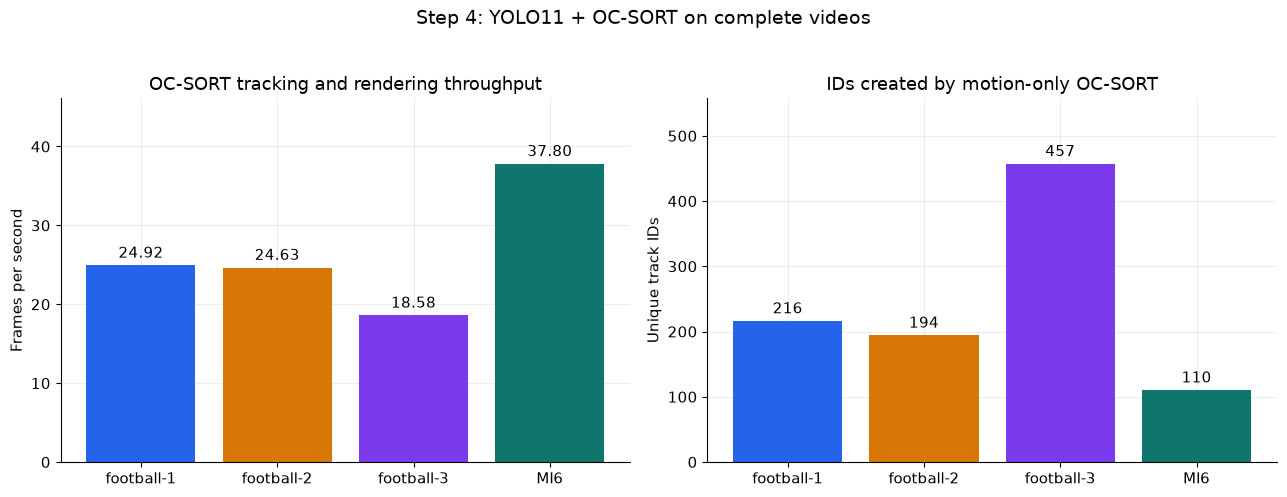

Saved figure: outputs\comparisons\figures\step4_ocsort_summary.png


In [16]:
ordered_ocsort = ocsort_summary.set_index("video")
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bar_colors = [COLORS[name] for name in ordered_ocsort.index]

fps_bars = axes[0].bar(ordered_ocsort.index, ordered_ocsort["processing_fps"], color=bar_colors)
axes[0].set_title("OC-SORT tracking and rendering throughput")
axes[0].set_ylabel("Frames per second")
axes[0].set_xlabel("")
axes[0].set_ylim(0, max(ordered_ocsort["processing_fps"]) * 1.22)
axes[0].bar_label(fps_bars, fmt="%.2f", padding=3)

id_bars = axes[1].bar(ordered_ocsort.index, ordered_ocsort["unique_global_ids"], color=bar_colors)
axes[1].set_title("IDs created by motion-only OC-SORT")
axes[1].set_ylabel("Unique track IDs")
axes[1].set_xlabel("")
axes[1].set_ylim(0, max(ordered_ocsort["unique_global_ids"]) * 1.22)
axes[1].bar_label(id_bars, fmt="%.0f", padding=3)

figure.suptitle("Step 4: YOLO11 + OC-SORT on complete videos", fontsize=14, y=1.03)
figure.tight_layout()
ocsort_figure_path = FIGURE_ROOT / "step4_ocsort_summary.png"
figure.savefig(ocsort_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved figure: {ocsort_figure_path.relative_to(PROJECT_ROOT)}")

In [17]:
from scenecut_tracking.video_gallery import build_video_gallery

gallery_path = build_video_gallery(PROJECT_ROOT)
print(f"Video webpage refreshed: {gallery_path.relative_to(PROJECT_ROOT)}")

Video webpage refreshed: outputs\reports\video_gallery.html


## Takeaways — Step 4

- All four OC-SORT outputs preserve every source frame and the original 30 FPS.
- `MI6` had the highest measured tracking/rendering throughput
  (37.80 FPS).
- `football-3` created the most IDs (457),
  making it the strongest fragmentation candidate for later comparison.
- Created IDs are a behavioral diagnostic, **not** a true ID-switch count. Identity
  ground truth is required for IDF1, HOTA, MOTA, and validated switch counts.
- Annotated videos are intentionally kept out of the notebook and presented in
  `outputs/reports/video_gallery.html`.

The next section will run Deep OC-SORT's motion-plus-appearance association while
keeping the four YOLO11 detection caches fixed.

## Step 5 — YOLO11 + Deep OC-SORT

Deep OC-SORT keeps OC-SORT's observation-centric motion model and adds
pretrained OSNet appearance embeddings plus camera-motion compensation.
The detector remains unchanged.

To make Steps 5 and 6 fast and controlled, OSNet is executed once for every
cached YOLO11 detection. Both Deep OC-SORT methods reuse the same immutable
appearance cache.

In [18]:
from scenecut_tracking.appearance_cache import AppearanceCache, build_appearance_cache
from scenecut_tracking.deep_runner import run_deep_video

APPEARANCE_ROOT = PROJECT_ROOT / CONFIG["experiment"]["appearance_cache_root"]
APPEARANCE_ROOT.mkdir(parents=True, exist_ok=True)
appearance_results: dict[str, dict] = {}
deep_results: dict[str, dict] = {}
cut_results: dict[str, dict] = {}

def build_or_validate_appearance_cache(video_name: str) -> dict:
    video_path = VIDEO_PATHS[video_name]
    detection_path = CACHE_ROOT / f"{video_name}_yolo11n_cpu.npz"
    appearance_path = APPEARANCE_ROOT / f"{video_name}_osnet_x0_25_msmt17_cpu.npz"
    detection_cache = DetectionCache.load(detection_path)

    if appearance_path.exists():
        appearance_cache = AppearanceCache.load(appearance_path)
        action = "validated existing cache"
    else:
        print(f"Extracting OSNet embeddings for every {video_name} detection...")
        appearance_cache = build_appearance_cache(
            video_path=video_path,
            detection_cache_path=detection_path,
            reid_config=CONFIG["reid"],
            project_root=PROJECT_ROOT,
        )
        appearance_cache.save(appearance_path)
        action = "built new cache"

    appearance_cache.validate(detection_cache)
    metadata = appearance_cache.metadata
    result = {
        "video": video_name,
        "status": action,
        "source_frames": metadata["video"]["frame_count"],
        "embedding_rows": metadata["detection_rows"],
        "embedding_width": metadata["embedding_width"],
        "elapsed_seconds": metadata["runtime"]["elapsed_seconds"],
        "appearance_fps": metadata["runtime"]["processing_fps"],
        "cache_path": str(appearance_path.relative_to(PROJECT_ROOT)),
    }
    appearance_results[video_name] = result
    return result

def run_or_validate_deep(video_name: str, mode: str) -> dict:
    if mode not in {"deep_ocsort", "deep_ocsort_scenecut"}:
        raise ValueError(mode)
    video_path = VIDEO_PATHS[video_name]
    detection_path = CACHE_ROOT / f"{video_name}_yolo11n_cpu.npz"
    appearance_path = APPEARANCE_ROOT / f"{video_name}_osnet_x0_25_msmt17_cpu.npz"
    output_dir = EXPERIMENT_ROOT / video_name / mode
    metrics_path = output_dir / "metrics.json"
    annotated_path = output_dir / "annotated.mp4"
    browser_path = output_dir / "annotated_h264.mp4"

    if metrics_path.exists() and annotated_path.exists() and browser_path.exists():
        metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
        action = "validated existing run"
    else:
        print(f"Running {mode} on every frame of {video_name}...")
        metrics = run_deep_video(
            mode=mode,
            video_path=video_path,
            detection_cache_path=detection_path,
            appearance_cache_path=appearance_path,
            output_dir=output_dir,
            config=CONFIG,
            project_root=PROJECT_ROOT,
        )
        action = "built new run"

    source_meta = inspect_video(video_path)
    annotated_meta = inspect_video(annotated_path)
    browser_meta = inspect_video(browser_path)
    assert metrics["frames"] == source_meta["frames"]
    assert annotated_meta["frames"] == source_meta["frames"]
    assert browser_meta["frames"] == source_meta["frames"]
    assert abs(browser_meta["fps"] - source_meta["fps"]) < 0.01
    assert abs(browser_meta["duration_seconds"] - source_meta["duration_seconds"]) < 0.05

    tracks = pd.read_csv(output_dir / "tracks.csv")
    assert len(tracks) == metrics["track_rows"]
    assert np.isfinite(tracks[["x1", "y1", "x2", "y2"]].to_numpy()).all()

    result = {
        "video": video_name,
        "method": mode,
        "status": action,
        "source_frames": source_meta["frames"],
        "output_frames": browser_meta["frames"],
        "duration_seconds": browser_meta["duration_seconds"],
        "processing_fps": metrics["processing_fps"],
        "elapsed_seconds": metrics["elapsed_seconds"],
        "track_rows": metrics["track_rows"],
        "unique_global_ids": metrics["unique_global_ids"],
        "detected_scene_cuts": metrics["detected_scene_cuts"],
        "accepted_recoveries": metrics["accepted_recoveries"],
        "average_recovery_similarity": metrics["average_recovery_similarity"],
        "finite_track_boxes": True,
        "output_dir": str(output_dir.relative_to(PROJECT_ROOT)),
    }
    if mode == "deep_ocsort":
        deep_results[video_name] = result
    else:
        cut_results[video_name] = result
    return result

### Build shared OSNet appearance caches

In [19]:
football_1_appearance = build_or_validate_appearance_cache('football-1')
football_1_appearance

{'video': 'football-1',
 'status': 'validated existing cache',
 'source_frames': 1122,
 'embedding_rows': 8364,
 'embedding_width': 512,
 'elapsed_seconds': 305.50463239999954,
 'appearance_fps': 3.6726120687131085,
 'cache_path': 'outputs\\appearance_cache\\football-1_osnet_x0_25_msmt17_cpu.npz'}

In [20]:
football_2_appearance = build_or_validate_appearance_cache('football-2')
football_2_appearance

{'video': 'football-2',
 'status': 'validated existing cache',
 'source_frames': 722,
 'embedding_rows': 6179,
 'embedding_width': 512,
 'elapsed_seconds': 238.50593659999868,
 'appearance_fps': 3.027178318042772,
 'cache_path': 'outputs\\appearance_cache\\football-2_osnet_x0_25_msmt17_cpu.npz'}

In [21]:
football_3_appearance = build_or_validate_appearance_cache('football-3')
football_3_appearance

{'video': 'football-3',
 'status': 'validated existing cache',
 'source_frames': 842,
 'embedding_rows': 13947,
 'embedding_width': 512,
 'elapsed_seconds': 481.89420979999704,
 'appearance_fps': 1.7472714609902855,
 'cache_path': 'outputs\\appearance_cache\\football-3_osnet_x0_25_msmt17_cpu.npz'}

In [22]:
mi6_appearance = build_or_validate_appearance_cache('MI6')
mi6_appearance

{'video': 'MI6',
 'status': 'validated existing cache',
 'source_frames': 918,
 'embedding_rows': 4203,
 'embedding_width': 512,
 'elapsed_seconds': 148.83578799999668,
 'appearance_fps': 6.1678713993170815,
 'cache_path': 'outputs\\appearance_cache\\MI6_osnet_x0_25_msmt17_cpu.npz'}

In [23]:
appearance_summary = pd.DataFrame(appearance_results.values()).set_index("video").loc[
    ["football-1", "football-2", "football-3", "MI6"]
].reset_index()
assert (appearance_summary["source_frames"] > 0).all()
assert (appearance_summary["embedding_rows"] > 0).all()
assert (appearance_summary["embedding_width"] > 0).all()
display(appearance_summary.style.format({"elapsed_seconds": "{:.2f}", "appearance_fps": "{:.2f}"}))

,video,status,source_frames,embedding_rows,embedding_width,elapsed_seconds,appearance_fps,cache_path
0,football-1,validated existing cache,1122,8364,512,305.50,3.67,outputs\appearance_cache\football-1_osnet_x0_25_msmt17_cpu.npz
1,football-2,validated existing cache,722,6179,512,238.51,3.03,outputs\appearance_cache\football-2_osnet_x0_25_msmt17_cpu.npz
2,football-3,validated existing cache,842,13947,512,481.89,1.75,outputs\appearance_cache\football-3_osnet_x0_25_msmt17_cpu.npz
3,MI6,validated existing cache,918,4203,512,148.84,6.17,outputs\appearance_cache\MI6_osnet_x0_25_msmt17_cpu.npz


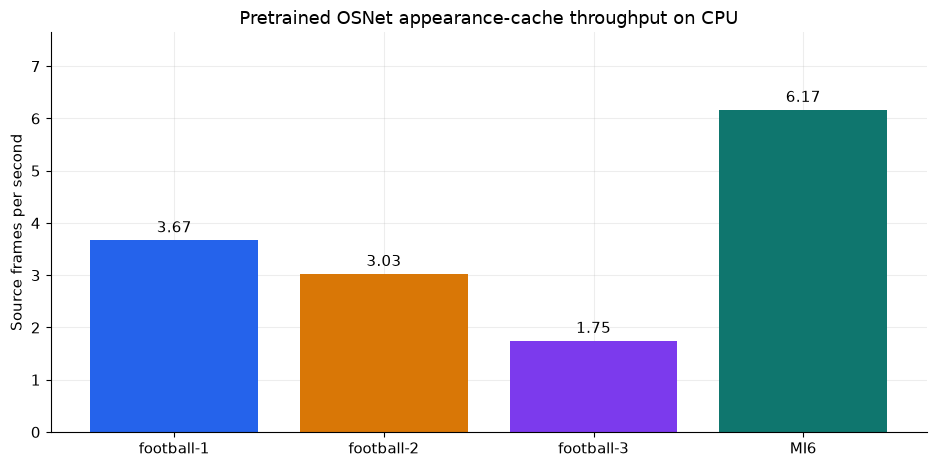

Saved figure: outputs\comparisons\figures\step5_osnet_cache_summary.png


In [24]:
appearance_plot = appearance_summary.set_index("video")
figure, axis = plt.subplots(figsize=(9.5, 4.8))
bars = axis.bar(
    appearance_plot.index,
    appearance_plot["appearance_fps"],
    color=[COLORS[name] for name in appearance_plot.index],
)
axis.set_title("Pretrained OSNet appearance-cache throughput on CPU")
axis.set_ylabel("Source frames per second")
axis.set_xlabel("")
axis.set_ylim(0, max(appearance_plot["appearance_fps"]) * 1.24)
axis.bar_label(bars, fmt="%.2f", padding=3)
figure.tight_layout()
appearance_figure_path = FIGURE_ROOT / "step5_osnet_cache_summary.png"
figure.savefig(appearance_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved figure: {appearance_figure_path.relative_to(PROJECT_ROOT)}")

### Run Deep OC-SORT on all four videos

In [25]:
football_1_deep = run_or_validate_deep('football-1', 'deep_ocsort')
football_1_deep

{'video': 'football-1',
 'method': 'deep_ocsort',
 'status': 'validated existing run',
 'source_frames': 1122,
 'output_frames': 1122,
 'duration_seconds': 37.4,
 'processing_fps': 38.74409556989834,
 'elapsed_seconds': 28.959251300002506,
 'track_rows': 6245,
 'unique_global_ids': 209,
 'detected_scene_cuts': 0,
 'accepted_recoveries': 0,
 'average_recovery_similarity': None,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-1\\deep_ocsort'}

In [26]:
football_2_deep = run_or_validate_deep('football-2', 'deep_ocsort')
football_2_deep

{'video': 'football-2',
 'method': 'deep_ocsort',
 'status': 'validated existing run',
 'source_frames': 722,
 'output_frames': 722,
 'duration_seconds': 24.066666666666666,
 'processing_fps': 32.675284629674785,
 'elapsed_seconds': 22.09621150000021,
 'track_rows': 4736,
 'unique_global_ids': 181,
 'detected_scene_cuts': 0,
 'accepted_recoveries': 0,
 'average_recovery_similarity': None,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-2\\deep_ocsort'}

In [27]:
football_3_deep = run_or_validate_deep('football-3', 'deep_ocsort')
football_3_deep

{'video': 'football-3',
 'method': 'deep_ocsort',
 'status': 'validated existing run',
 'source_frames': 842,
 'output_frames': 842,
 'duration_seconds': 28.066666666666666,
 'processing_fps': 25.16569608375047,
 'elapsed_seconds': 33.45824400000129,
 'track_rows': 10105,
 'unique_global_ids': 395,
 'detected_scene_cuts': 0,
 'accepted_recoveries': 0,
 'average_recovery_similarity': None,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-3\\deep_ocsort'}

In [28]:
mi6_deep = run_or_validate_deep('MI6', 'deep_ocsort')
mi6_deep

{'video': 'MI6',
 'method': 'deep_ocsort',
 'status': 'validated existing run',
 'source_frames': 918,
 'output_frames': 918,
 'duration_seconds': 30.6,
 'processing_fps': 59.75127885797211,
 'elapsed_seconds': 15.363687900004152,
 'track_rows': 3644,
 'unique_global_ids': 101,
 'detected_scene_cuts': 0,
 'accepted_recoveries': 0,
 'average_recovery_similarity': None,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\MI6\\deep_ocsort'}

In [29]:
deep_summary = pd.DataFrame(deep_results.values()).set_index("video").loc[
    ["football-1", "football-2", "football-3", "MI6"]
].reset_index()
assert (deep_summary["source_frames"] == deep_summary["output_frames"]).all()
assert deep_summary["finite_track_boxes"].all()
display(deep_summary.style.format({"duration_seconds": "{:.2f}", "processing_fps": "{:.2f}", "elapsed_seconds": "{:.2f}"}))
print("PASS: all four Deep OC-SORT videos contain every source frame.")

,video,method,status,source_frames,output_frames,duration_seconds,processing_fps,elapsed_seconds,track_rows,unique_global_ids,detected_scene_cuts,accepted_recoveries,average_recovery_similarity,finite_track_boxes,output_dir
0,football-1,deep_ocsort,validated existing run,1122,1122,37.40,38.74,28.96,6245,209,0,0,None,True,outputs\experiments\football-1\deep_ocsort
1,football-2,deep_ocsort,validated existing run,722,722,24.07,32.68,22.10,4736,181,0,0,None,True,outputs\experiments\football-2\deep_ocsort
2,football-3,deep_ocsort,validated existing run,842,842,28.07,25.17,33.46,10105,395,0,0,None,True,outputs\experiments\football-3\deep_ocsort
3,MI6,deep_ocsort,validated existing run,918,918,30.60,59.75,15.36,3644,101,0,0,None,True,outputs\experiments\MI6\deep_ocsort


PASS: all four Deep OC-SORT videos contain every source frame.


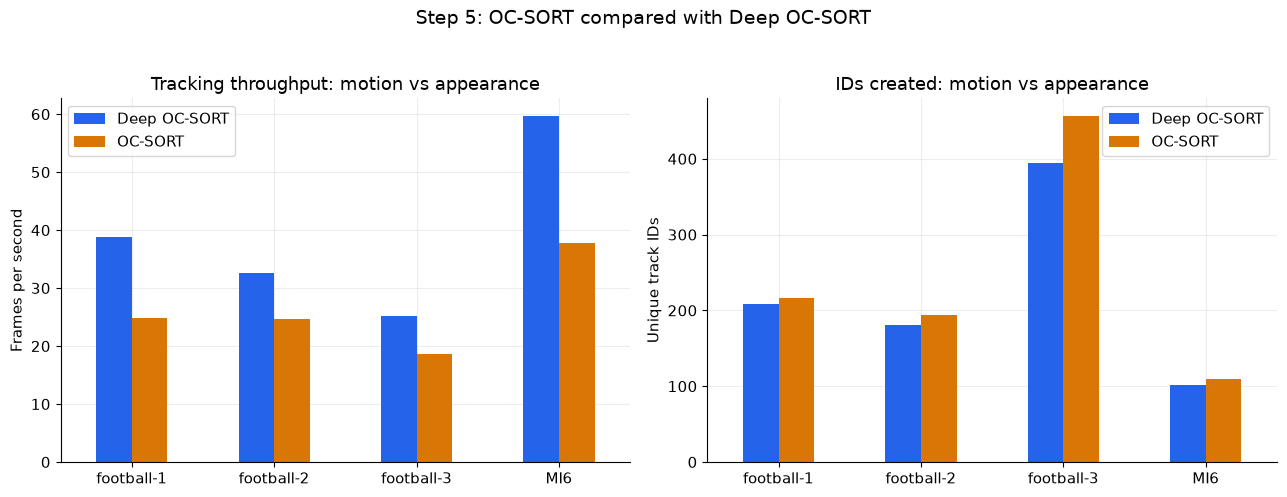

Saved figure: outputs\comparisons\figures\step5_ocsort_vs_deep_ocsort.png


In [30]:
baseline_for_compare = ocsort_summary[["video", "processing_fps", "unique_global_ids"]].copy()
baseline_for_compare["method_label"] = "OC-SORT"
deep_for_compare = deep_summary[["video", "processing_fps", "unique_global_ids"]].copy()
deep_for_compare["method_label"] = "Deep OC-SORT"
step5_compare = pd.concat([baseline_for_compare, deep_for_compare], ignore_index=True)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for index, metric in enumerate(("processing_fps", "unique_global_ids")):
    pivot = step5_compare.pivot(index="video", columns="method_label", values=metric).loc[
        ["football-1", "football-2", "football-3", "MI6"]
    ]
    pivot.plot(kind="bar", ax=axes[index], rot=0, color=["#2563EB", "#D97706"])
    axes[index].set_xlabel("")
    axes[index].legend(title="")
axes[0].set_title("Tracking throughput: motion vs appearance")
axes[0].set_ylabel("Frames per second")
axes[1].set_title("IDs created: motion vs appearance")
axes[1].set_ylabel("Unique track IDs")
figure.suptitle("Step 5: OC-SORT compared with Deep OC-SORT", fontsize=14, y=1.03)
figure.tight_layout()
step5_figure_path = FIGURE_ROOT / "step5_ocsort_vs_deep_ocsort.png"
figure.savefig(step5_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved figure: {step5_figure_path.relative_to(PROJECT_ROOT)}")

## Step 6 — Deep OC-SORT + hard-scene-cut recovery

On each hard cut, active Deep OC-SORT tracks, Kalman state, and camera-motion
history are discarded. The long-term OSNet identity gallery remains. A new
local track receives a previous global ID only when conservative one-to-one
cosine matching exceeds the configured threshold; otherwise it gets a new ID.

In [31]:
football_1_cut = run_or_validate_deep('football-1', 'deep_ocsort_scenecut')
football_1_cut

{'video': 'football-1',
 'method': 'deep_ocsort_scenecut',
 'status': 'validated existing run',
 'source_frames': 1122,
 'output_frames': 1122,
 'duration_seconds': 37.4,
 'processing_fps': 17.31526044228127,
 'elapsed_seconds': 64.79833230000077,
 'track_rows': 6357,
 'unique_global_ids': 226,
 'detected_scene_cuts': 11,
 'accepted_recoveries': 27,
 'average_recovery_similarity': 0.8427352220923813,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-1\\deep_ocsort_scenecut'}

In [32]:
football_2_cut = run_or_validate_deep('football-2', 'deep_ocsort_scenecut')
football_2_cut

{'video': 'football-2',
 'method': 'deep_ocsort_scenecut',
 'status': 'validated existing run',
 'source_frames': 722,
 'output_frames': 722,
 'duration_seconds': 24.066666666666666,
 'processing_fps': 16.686705080585938,
 'elapsed_seconds': 43.26797870000155,
 'track_rows': 4843,
 'unique_global_ids': 195,
 'detected_scene_cuts': 18,
 'accepted_recoveries': 110,
 'average_recovery_similarity': 0.8594076237895272,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-2\\deep_ocsort_scenecut'}

In [33]:
football_3_cut = run_or_validate_deep('football-3', 'deep_ocsort_scenecut')
football_3_cut

{'video': 'football-3',
 'method': 'deep_ocsort_scenecut',
 'status': 'validated existing run',
 'source_frames': 842,
 'output_frames': 842,
 'duration_seconds': 28.066666666666666,
 'processing_fps': 14.609872758592918,
 'elapsed_seconds': 57.632260999998834,
 'track_rows': 10213,
 'unique_global_ids': 394,
 'detected_scene_cuts': 6,
 'accepted_recoveries': 39,
 'average_recovery_similarity': 0.878556992763128,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\football-3\\deep_ocsort_scenecut'}

In [34]:
mi6_cut = run_or_validate_deep('MI6', 'deep_ocsort_scenecut')
mi6_cut

{'video': 'MI6',
 'method': 'deep_ocsort_scenecut',
 'status': 'validated existing run',
 'source_frames': 918,
 'output_frames': 918,
 'duration_seconds': 30.6,
 'processing_fps': 18.880556503045668,
 'elapsed_seconds': 48.62144819999958,
 'track_rows': 3747,
 'unique_global_ids': 89,
 'detected_scene_cuts': 9,
 'accepted_recoveries': 26,
 'average_recovery_similarity': 0.8002574054094461,
 'finite_track_boxes': True,
 'output_dir': 'outputs\\experiments\\MI6\\deep_ocsort_scenecut'}

In [35]:
cut_summary = pd.DataFrame(cut_results.values()).set_index("video").loc[
    ["football-1", "football-2", "football-3", "MI6"]
].reset_index()
assert (cut_summary["source_frames"] == cut_summary["output_frames"]).all()
assert cut_summary["finite_track_boxes"].all()
assert (cut_summary["detected_scene_cuts"] >= 0).all()
display(cut_summary.style.format({
    "duration_seconds": "{:.2f}",
    "processing_fps": "{:.2f}",
    "elapsed_seconds": "{:.2f}",
    "average_recovery_similarity": lambda value: "—" if pd.isna(value) else f"{value:.3f}",
}))
print("PASS: all four cut-aware videos contain every source frame.")

,video,method,status,source_frames,output_frames,duration_seconds,processing_fps,elapsed_seconds,track_rows,unique_global_ids,detected_scene_cuts,accepted_recoveries,average_recovery_similarity,finite_track_boxes,output_dir
0,football-1,deep_ocsort_scenecut,validated existing run,1122,1122,37.40,17.32,64.80,6357,226,11,27,0.843,True,outputs\experiments\football-1\deep_ocsort_scenecut
1,football-2,deep_ocsort_scenecut,validated existing run,722,722,24.07,16.69,43.27,4843,195,18,110,0.859,True,outputs\experiments\football-2\deep_ocsort_scenecut
2,football-3,deep_ocsort_scenecut,validated existing run,842,842,28.07,14.61,57.63,10213,394,6,39,0.879,True,outputs\experiments\football-3\deep_ocsort_scenecut
3,MI6,deep_ocsort_scenecut,validated existing run,918,918,30.60,18.88,48.62,3747,89,9,26,0.800,True,outputs\experiments\MI6\deep_ocsort_scenecut


PASS: all four cut-aware videos contain every source frame.


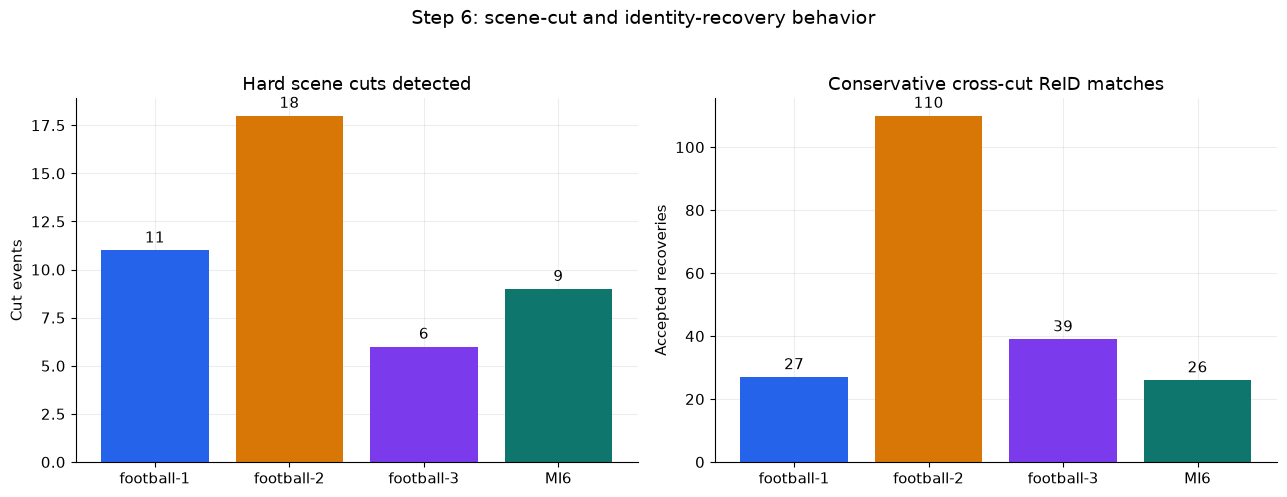

Saved figure: outputs\comparisons\figures\step6_scene_cut_recovery_summary.png


In [36]:
event_plot = cut_summary.set_index("video")
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))
colors = [COLORS[name] for name in event_plot.index]
cut_bars = axes[0].bar(event_plot.index, event_plot["detected_scene_cuts"], color=colors)
axes[0].set_title("Hard scene cuts detected")
axes[0].set_ylabel("Cut events")
axes[0].set_xlabel("")
axes[0].bar_label(cut_bars, fmt="%.0f", padding=3)
recovery_bars = axes[1].bar(event_plot.index, event_plot["accepted_recoveries"], color=colors)
axes[1].set_title("Conservative cross-cut ReID matches")
axes[1].set_ylabel("Accepted recoveries")
axes[1].set_xlabel("")
axes[1].bar_label(recovery_bars, fmt="%.0f", padding=3)
figure.suptitle("Step 6: scene-cut and identity-recovery behavior", fontsize=14, y=1.03)
figure.tight_layout()
event_figure_path = FIGURE_ROOT / "step6_scene_cut_recovery_summary.png"
figure.savefig(event_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved figure: {event_figure_path.relative_to(PROJECT_ROOT)}")

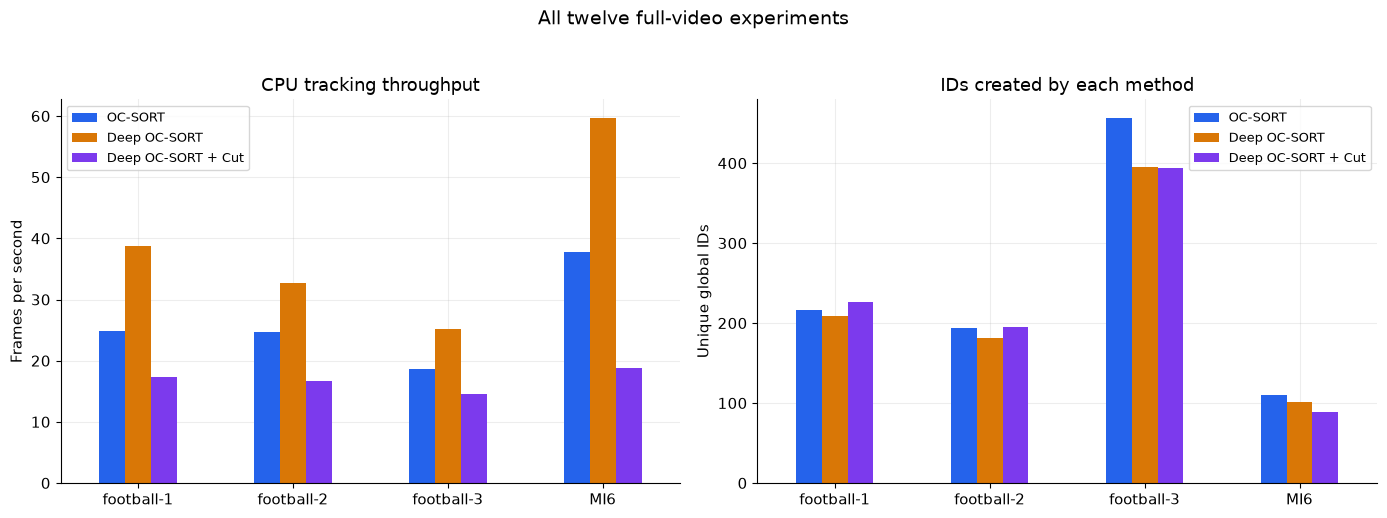

Saved figure: outputs\comparisons\figures\steps4_to_6_all_methods_comparison.png


In [37]:
all_method_rows = []
for table, method_label in (
    (ocsort_summary, "OC-SORT"),
    (deep_summary, "Deep OC-SORT"),
    (cut_summary, "Deep OC-SORT + Cut"),
):
    selected = table[["video", "processing_fps", "unique_global_ids"]].copy()
    selected["method_label"] = method_label
    all_method_rows.append(selected)
final_comparison = pd.concat(all_method_rows, ignore_index=True)

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
method_colors = ["#2563EB", "#D97706", "#7C3AED"]
for axis, metric, title, ylabel in (
    (axes[0], "processing_fps", "CPU tracking throughput", "Frames per second"),
    (axes[1], "unique_global_ids", "IDs created by each method", "Unique global IDs"),
):
    pivot = final_comparison.pivot(index="video", columns="method_label", values=metric).loc[
        ["football-1", "football-2", "football-3", "MI6"]
    ]
    pivot = pivot[["OC-SORT", "Deep OC-SORT", "Deep OC-SORT + Cut"]]
    pivot.plot(kind="bar", ax=axis, rot=0, color=method_colors)
    axis.set_title(title)
    axis.set_ylabel(ylabel)
    axis.set_xlabel("")
    axis.legend(title="", fontsize=9)
figure.suptitle("All twelve full-video experiments", fontsize=14, y=1.03)
figure.tight_layout()
final_figure_path = FIGURE_ROOT / "steps4_to_6_all_methods_comparison.png"
figure.savefig(final_figure_path, dpi=180, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved figure: {final_figure_path.relative_to(PROJECT_ROOT)}")

In [38]:
gallery_path = build_video_gallery(PROJECT_ROOT)
print(f"Video webpage refreshed: {gallery_path.relative_to(PROJECT_ROOT)}")

Video webpage refreshed: outputs\reports\video_gallery.html


## Takeaways — Steps 5 and 6

- Standard Deep OC-SORT created fewer IDs than motion-only OC-SORT on all four
  videos: football-1 (209 vs 216), football-2 (181 vs 194), football-3
  (395 vs 457), and MI6 (101 vs 110). This is a fragmentation diagnostic, not
  an accuracy claim.
- Cut-aware Deep OC-SORT reset invalid short-term motion **44** times and
  accepted **202** one-to-one appearance matches above the configured
  conservative threshold.
- Cut-aware runs are slower because they perform scene analysis and long-term global
  identity management. Their ID counts may increase or decrease depending on how
  many conservative matches are rejected; without ground truth, neither direction
  proves better identity accuracy.
- All videos are in `outputs/reports/video_gallery.html`; the notebook intentionally
  contains no embedded video tags.

The valid conclusion is architectural: hard cuts invalidate motion state, while
appearance memory permits selective cross-shot identity recovery. Ground-truth identity
annotations are required to quantify whether those recoveries are correct.

## Final clip — Joker.mp4

This final pass runs the same three CPU-only methods on every frame of `data/Joker.mp4`. The gallery displays this source as **Final clip**.

In [ ]:
# Build the shared YOLO11 detection cache for the final clip.
joker_cache = build_or_validate_cache("Joker")
print(joker_cache)

In [ ]:
# Build the shared OSNet appearance cache used by Deep OC-SORT and cut-aware recovery.
joker_appearance = build_or_validate_appearance_cache("Joker")
print(joker_appearance)

In [ ]:
# Run/validate all three tracking variants on Joker.mp4.
joker_ocsort = run_or_validate_ocsort("Joker")
joker_deep = run_or_validate_deep("Joker", "deep_ocsort")
joker_cut = run_or_validate_deep("Joker", "deep_ocsort_scenecut")

In [ ]:
joker_summary = pd.DataFrame([joker_ocsort, joker_deep, joker_cut])
joker_summary = joker_summary[[c for c in ["video", "method", "frames", "duration_seconds", "processing_fps", "unique_global_ids", "detected_scene_cuts", "accepted_recoveries", "mean_recovery_similarity"] if c in joker_summary.columns]]
display(joker_summary.style.format({"duration_seconds":"{:.2f}", "processing_fps":"{:.2f}", "mean_recovery_similarity":"{:.3f}"}, na_rep="—"))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = ["OC-SORT", "Deep OC-SORT", "Deep OC-SORT + Cut"]
colors = ["#2563eb", "#0f766e", "#d97706"]
axes[0].bar(labels, joker_summary["processing_fps"], color=colors)
axes[0].set_title("Final clip throughput")
axes[0].set_ylabel("FPS (higher is better)")
axes[0].tick_params(axis="x", rotation=18)
axes[1].bar(labels, joker_summary["unique_global_ids"], color=colors)
axes[1].set_title("Final clip identity count")
axes[1].set_ylabel("Unique IDs (lower is not automatically better)")
axes[1].tick_params(axis="x", rotation=18)
figure.tight_layout()
plt.show()

In [ ]:
gallery_path = build_video_gallery(PROJECT_ROOT)
print(f"Video webpage refreshed: {gallery_path}")